Machine Learning Models

In [258]:
import pandas as pd

In [299]:
df = pd.read_csv("customer_churn.csv")

In [260]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [261]:
df.shape

(7043, 21)

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [263]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [264]:
df.duplicated().sum()

np.int64(0)

1. Data Manipulation

In [265]:
customer_5 = df.iloc[:, 4]
customer_5.head()

,Dependents
0,No
1,No
2,No
3,No
4,No


In [266]:
customer_15 = df.iloc[:, 14]
customer_15.head()

,StreamingMovies
0,No
1,No
2,No
3,No
4,No


In [267]:
senior_male_electronic = df[
    (df["gender"] == "Male") &
    (df["SeniorCitizen"] == 1) &
    (df["PaymentMethod"] == "Electronic check")
]
senior_male_electronic.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
78,0191-ZHSKZ,Male,1,No,No,30,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.3,No
91,2424-WVHPL,Male,1,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.7,No


In [268]:
customer_total_tenure = df[
    (df["tenure"] > 70) |
    (df["MonthlyCharges"] > 100)
]
customer_total_tenure.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes
14,5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No


In [269]:
two_mail_yes = df[
    (df["Contract"] == "Two year") &
    (df["PaymentMethod"] == "Mailed check") &
    (df["Churn"] == "Yes")
]
two_mail_yes.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
268,6323-AYBRX,Male,0,No,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1099.6,Yes
5947,7951-QKZPL,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,24.50,740.3,Yes
6680,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,95.50,4627.85,Yes


In [270]:
customer_333 = df.sample(n=333)
customer_333.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
64,5698-BQJOH,Female,0,No,No,9,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,94.40,857.25,Yes
6496,2474-BRUCM,Male,1,Yes,No,40,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,101.85,4086.3,Yes
2086,2955-BJZHG,Male,0,Yes,Yes,17,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,No,Electronic check,80.85,1400.85,Yes
691,6663-JOCQO,Male,0,Yes,Yes,31,Yes,Yes,DSL,Yes,...,No,Yes,No,Yes,One year,Yes,Bank transfer (automatic),75.25,2344.5,No
3925,9938-ZREHM,Female,0,Yes,No,37,Yes,Yes,DSL,No,...,No,Yes,No,Yes,One year,No,Mailed check,72.10,2658.4,No


In [271]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


2. Data Visualization:

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns

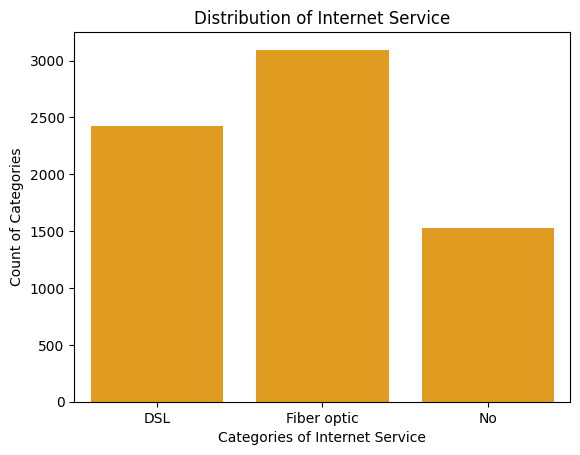

In [273]:
sns.countplot(x="InternetService", data=df, color="orange")

plt.xlabel("Categories of Internet Service")
plt.ylabel("Count of Categories")
plt.title("Distribution of Internet Service")

plt.show()

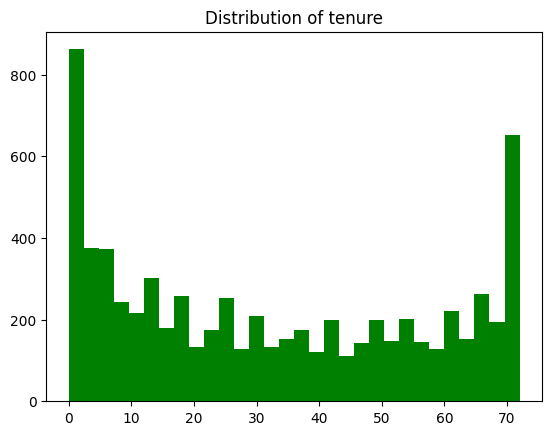

In [274]:
plt.hist(df["tenure"], bins=30, color="green")

plt.title("Distribution of tenure")

plt.show()

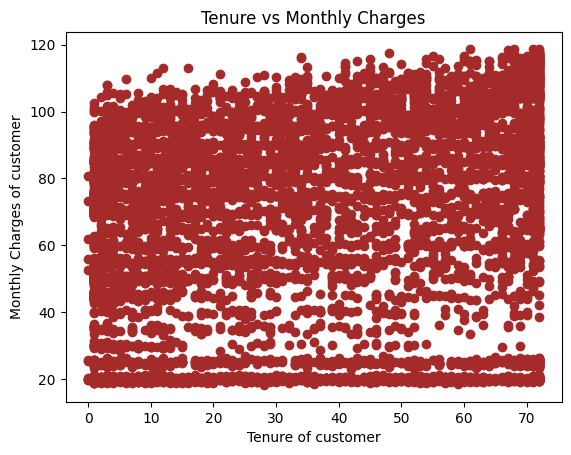

In [275]:
plt.scatter(df["tenure"], df["MonthlyCharges"], color="brown")

plt.xlabel("Tenure of customer")
plt.ylabel("Monthly Charges of customer")
plt.title("Tenure vs Monthly Charges")

plt.show()

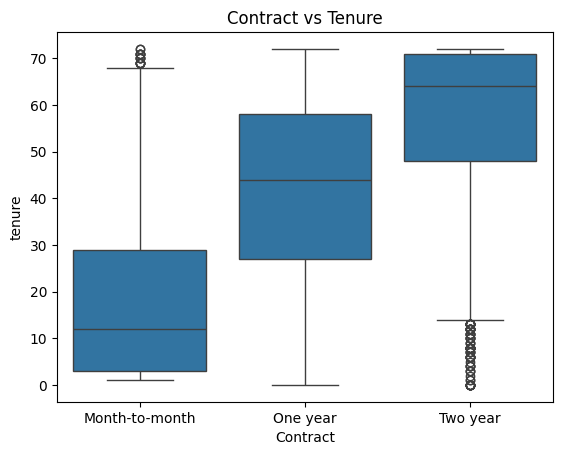

In [276]:
sns.boxplot(x="Contract", y="tenure", data=df)

plt.xlabel("Contract")
plt.ylabel("tenure")
plt.title("Contract vs Tenure")

plt.show()

3. Linear Regression

In [277]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [278]:
X = df[["tenure"]]
y = df["MonthlyCharges"]

In [279]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4930, 1)
(2113, 1)
(4930,)
(2113,)


In [280]:
lr.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [281]:
print("Slope/Coefficient:", lr.coef_)
print("Intercept:", lr.intercept_)

Slope/Coefficient: [0.30821548]
Intercept: 54.79837462739951


In [282]:
y_pred = lr.predict(X_test)
print(y_pred[:5])

[55.10659011 67.43520921 70.82557946 55.10659011 75.44881163]


In [283]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
185,24.80,55.106590
2715,25.25,67.435209
3825,19.35,70.825579
1807,76.35,55.106590
132,50.55,75.448812


In [284]:
import numpy as np

In [285]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 29.07936015646814


In [286]:
error = y_test - y_pred
print(error.head())

185    -30.306590
2715   -42.185209
3825   -51.475579
1807    21.243410
132    -24.898812
Name: MonthlyCharges, dtype: float64


4. Logistic Regression

In [287]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split


In [288]:
df = pd.read_csv("customer_churn.csv")

In [289]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [290]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [291]:
print(df['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [292]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42
)

In [293]:
print(X_train.shape)
print(X_test.shape)

(4577, 1)
(2466, 1)


In [297]:
log_model = LogisticRegression()

In [300]:
# Redefine X and y for Logistic Regression, ensuring y is discrete
X = df[['tenure']]
y = df['Churn']

# Perform train_test_split again with the correct X and y
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42
)

log_model.fit(X_train, y_train)
print("Model trained successfully for classification")

Model trained successfully for classification


In [301]:
y_pred = log_model.predict(X_test)

In [302]:
print(y_pred)

['No' 'No' 'No' ... 'No' 'No' 'No']


In [303]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1797    0]
 [ 669    0]]


In [304]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.7287104622871047


In [305]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

   Actual Predicted
0     Yes        No
1      No        No
2      No        No
3     Yes        No
4      No        No
5     Yes        No
6      No        No
7      No        No
8     Yes        No
9     Yes        No
10     No        No
11     No        No
12     No        No
13    Yes        No
14     No        No
15    Yes        No
16    Yes        No
17    Yes        No
18     No        No
19    Yes        No


In [306]:
X = df[['tenure', 'MonthlyCharges']]
y = df['Churn']

In [307]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [308]:
log_model = LogisticRegression()

In [309]:
log_model.fit(X_train, y_train)

LogisticRegression()

In [310]:
y_pred = log_model.predict(X_test)

In [311]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[944  92]
 [193 180]]


In [312]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.7977288857345636


In [313]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

   Actual Predicted
0     Yes        No
1      No        No
2      No        No
3     Yes       Yes
4      No        No
5     Yes        No
6      No        No
7      No        No
8     Yes        No
9     Yes        No
10     No        No
11     No        No
12     No        No
13    Yes       Yes
14     No        No
15    Yes       Yes
16    Yes        No
17    Yes       Yes
18     No        No
19    Yes        No


5. Decision Tree Classification

In [314]:
from sklearn.tree import DecisionTreeClassifier

In [315]:
X = df[['tenure']]
y = df['Churn']

In [316]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [317]:
dt_model = DecisionTreeClassifier()

In [318]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [319]:
y_pred = dt_model.predict(X_test)

In [320]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[951  85]
 [257 116]]


In [321]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.7572746628814763


In [322]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

   Actual Predicted
0     Yes       Yes
1      No        No
2      No        No
3     Yes       Yes
4      No        No
5     Yes        No
6      No        No
7      No        No
8     Yes        No
9     Yes       Yes
10     No       Yes
11     No        No
12     No        No
13    Yes        No
14     No        No
15    Yes        No
16    Yes        No
17    Yes       Yes
18     No        No
19    Yes        No


6. Random Forest Classification

In [323]:
from sklearn.ensemble import RandomForestClassifier

In [324]:
X = df[['tenure', 'MonthlyCharges']]
y = df['Churn']

In [325]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [326]:
rf_model = RandomForestClassifier()

In [327]:
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [328]:
y_pred = rf_model.predict(X_test)

In [329]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1337  202]
 [ 314  260]]


In [330]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.7557974443918599


In [331]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

   Actual Predicted
0     Yes       Yes
1      No        No
2      No        No
3     Yes       Yes
4      No        No
5     Yes        No
6      No        No
7      No        No
8     Yes        No
9     Yes        No
10     No        No
11     No        No
12     No        No
13    Yes        No
14     No        No
15    Yes       Yes
16    Yes        No
17    Yes       Yes
18     No        No
19    Yes       Yes


Deep Learning using Keras

In [332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [333]:
df = pd.read_csv("customer_churn.csv")

1. Data Manipulation

In [334]:
male_customers = df[df['gender'] == 'Male']

print(len(male_customers))

3555


In [335]:
dsl_customers = df[df['InternetService'] == 'DSL']

print(len(dsl_customers))

2421


In [336]:
new_customer = df[
    (df['gender'] == 'Female') &
    (df['SeniorCitizen'] == 1) &
    (df['PaymentMethod'] == 'Mailed check')
]

print(new_customer.head())

     customerID  gender  SeniorCitizen Partner Dependents  tenure  \
139  0390-DCFDQ  Female              1     Yes         No       1   
176  2656-FMOKZ  Female              1      No         No      15   
267  3197-ARFOY  Female              1      No         No      19   
451  5760-WRAHC  Female              1      No         No      22   
470  4933-IKULF  Female              1      No         No      17   

    PhoneService MultipleLines InternetService       OnlineSecurity  ...  \
139          Yes            No     Fiber optic                   No  ...   
176          Yes           Yes     Fiber optic                   No  ...   
267          Yes            No     Fiber optic                  Yes  ...   
451          Yes            No             DSL                  Yes  ...   
470          Yes            No              No  No internet service  ...   

        DeviceProtection          TechSupport          StreamingTV  \
139                   No                   No             

In [337]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

new_customer = df[
    (df['tenure'] < 10) |
    (df['TotalCharges'] < 500)
]

print(new_customer.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
2  3668-QPYBK    Male              0      No         No       2          Yes   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
2                No             DSL            Yes  ...               No   
4                No     Fiber optic             No  ...               No   
5               Yes     Fiber optic             No  ...              Yes   
7  No phone service             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

B. Data Visualization

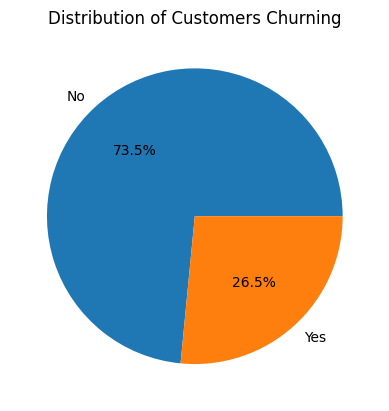

In [338]:
churn_count = df['Churn'].value_counts()

plt.pie(
    churn_count,
    labels=churn_count.index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Customers Churning")

plt.show()

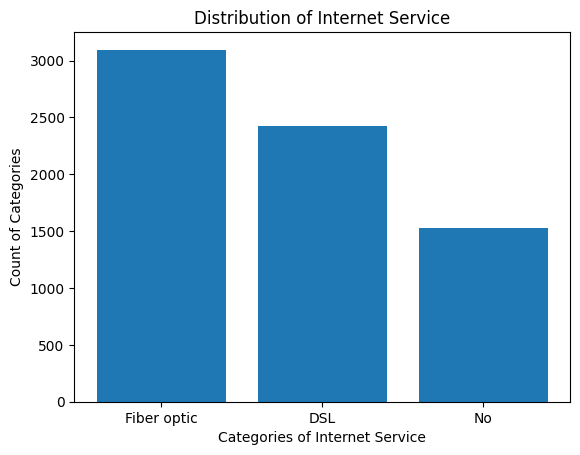

In [339]:
internet_service = df['InternetService'].value_counts()

plt.bar(
    internet_service.index,
    internet_service.values
)

plt.xlabel("Categories of Internet Service")
plt.ylabel("Count of Categories")
plt.title("Distribution of Internet Service")

plt.show()

C. Model Building using Keras


In [340]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [341]:
df = pd.read_csv("customer_churn.csv")

In [342]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

X = df[['tenure']]
y = df['Churn']

In [343]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [344]:
model = Sequential()

model.add(Dense(12, activation='relu', input_dim=1))

model.add(Dense(8, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [345]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [346]:
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    validation_data=(X_test, y_test)
)

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6913 - loss: 0.6990 - val_accuracy: 0.7283 - val_loss: 0.5120
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7373 - loss: 0.5126 - val_accuracy: 0.7283 - val_loss: 0.5112
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7373 - loss: 0.5118 - val_accuracy: 0.7283 - val_loss: 0.5105
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7369 - loss: 0.5128 - val_accuracy: 0.7283 - val_loss: 0.5118
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7373 - loss: 0.5123 - val_accuracy: 0.7283 - val_loss: 0.5110
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7404 - loss: 0.5128 - val_accuracy: 0.7283 - val_loss: 0.5104
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7373 - loss: 0.5135 - val_accuracy: 0.7283 - val_loss: 0.5144
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7373 - loss: 0.5162 - val_accu

In [347]:
y_pred = model.predict(X_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [348]:
y_pred = (y_pred > 0.5)

In [349]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1365  174]
 [ 360  214]]


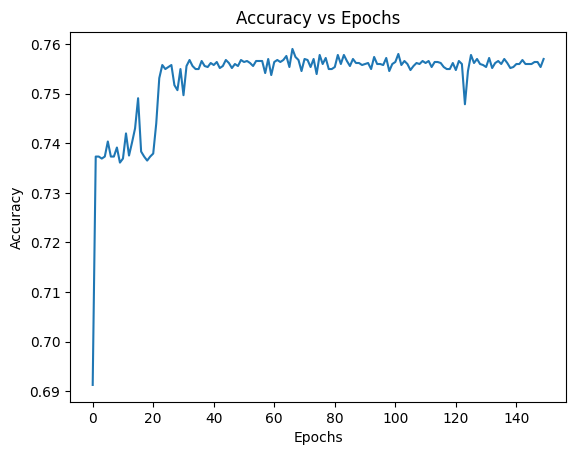

In [350]:
plt.plot(history.history['accuracy'])

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

using Dropout Layers


In [351]:
from tensorflow.keras.layers import Dropout

In [352]:
model2 = Sequential()

model2.add(Dense(12, activation='relu', input_dim=1))

model2.add(Dropout(0.3))

model2.add(Dense(8, activation='relu'))

model2.add(Dropout(0.2))

model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [353]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [354]:
history2 = model2.fit(
    X_train,
    y_train,
    epochs=150,
    validation_data=(X_test, y_test)
)

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6398 - loss: 1.5844 - val_accuracy: 0.7283 - val_loss: 0.6718
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6813 - loss: 0.8842 - val_accuracy: 0.7283 - val_loss: 0.5846
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6988 - loss: 0.6838 - val_accuracy: 0.7283 - val_loss: 0.5376
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7032 - loss: 0.6114 - val_accuracy: 0.7283 - val_loss: 0.5125
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7150 - loss: 0.5622 - val_accuracy: 0.7283 - val_loss: 0.5144
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7195 - loss: 0.5438 - val_accuracy: 0.7283 - val_loss: 0.5189
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7249 - loss: 0.5406 - val_accuracy: 0.7283 - val_loss: 0.5224
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7327 - loss: 0.5384 - val_accu

In [355]:
y_pred2 = model2.predict(X_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [356]:
y_pred2 = (y_pred2 > 0.5)

In [357]:
cm = confusion_matrix(y_test, y_pred2)

print(cm)

[[1539    0]
 [ 574    0]]


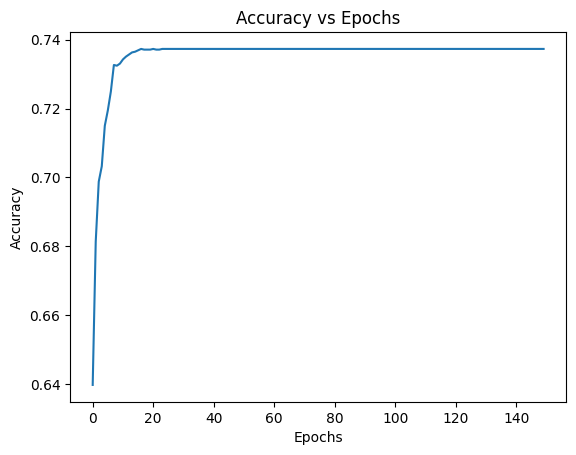

In [358]:
plt.plot(history2.history['accuracy'])

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

using Multiple Features

In [359]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df = df.dropna()

In [360]:
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

y = df['Churn']

In [361]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [362]:
model3 = Sequential()

model3.add(Dense(12, activation='relu', input_dim=3))

model3.add(Dense(8, activation='relu'))

model3.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [363]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [364]:
history3 = model3.fit(
    X_train,
    y_train,
    epochs=150,
    validation_data=(X_test, y_test)
)

Epoch 1/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7288 - loss: 11.2321 - val_accuracy: 0.7270 - val_loss: 0.5788
Epoch 2/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7300 - loss: 0.5807 - val_accuracy: 0.7408 - val_loss: 0.5834
Epoch 3/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7286 - loss: 0.5775 - val_accuracy: 0.7341 - val_loss: 0.5734
Epoch 4/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7343 - loss: 0.5767 - val_accuracy: 0.7341 - val_loss: 0.5681
Epoch 5/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7343 - loss: 0.5728 - val_accuracy: 0.7341 - val_loss: 0.5657
Epoch 6/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7343 - loss: 0.5670 - val_accuracy: 0.7341 - val_loss: 0.5636
Epoch 7/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7343 - loss: 0.5662 - val_accuracy: 0.7341 - val_loss: 0.5860
Epoch 8/150
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7343 - loss: 0.5692 - val_acc

In [365]:
y_pred3 = model3.predict(X_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [366]:
y_pred3 = (y_pred3 > 0.5)

In [367]:
cm = confusion_matrix(y_test, y_pred3)

print(cm)

[[1330  219]
 [ 272  289]]


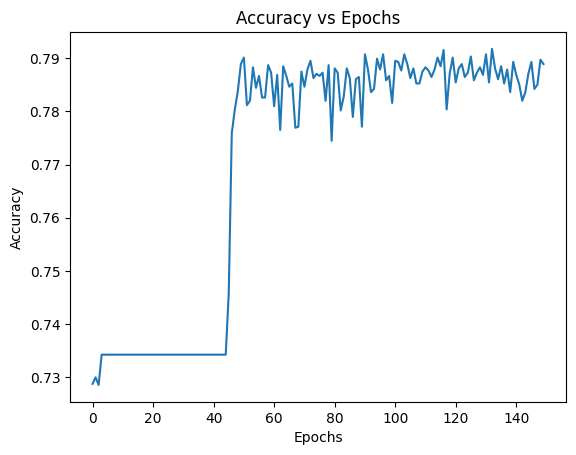

In [368]:
plt.plot(history3.history['accuracy'])

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

In [369]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
